# Historical Sentiment Trends in the NFL Draft

This project applies sentiment analysis to NFL prospect scouting writeups to examine how evaluative language varies across draft years, position groups, and player outcomes.

The analysis combines prospect bios with actual draft results to explore whether sentiment aligns with draft position, player grades, and positional trends over time.

## Imports and Setup

In [2]:
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Load Prospect Writeups

The first dataset contains NFL prospect bios, player grades, and draft classes.

In [4]:
nfl_prospects_df = pd.read_csv("nfl_prospects_writeup.csv")
nfl_prospects_df.head()

,Player,Player Bio,Player Grades,Draft Class,Link
0,Jadeveon Clowney,A physical specimen with a rare size-speed com...,7.5,2014,https://www.nfl.com/prospects/jadeveon-clowney...
1,Sammy Watkins,A legitimate No. 1-caliber receiver who steppe...,7.1,2014,https://www.nfl.com/prospects/sammy-watkins/32...
2,Anthony Barr,"A highly disruptive, athletic specimen with th...",7.0,2014,https://www.nfl.com/prospects/anthony-barr/320...
3,Khalil Mack,A havoc-wreaking rush linebacker with the burs...,7.0,2014,https://www.nfl.com/prospects/khalil-mack/3200...
4,Jake Matthews,"Smart, tough, versatile franchise left tackle ...",7.0,2014,https://www.nfl.com/prospects/jake-matthews/32...


In [5]:
nfl_prospects_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         4382 non-null   object 
 1   Player Bio     4382 non-null   object 
 2   Player Grades  4382 non-null   float64
 3   Draft Class    4382 non-null   int64  
 4   Link           4382 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 171.3+ KB


In [6]:
# Drop unused link column
nfl_prospects_df = nfl_prospects_df.drop(columns=["Link"])
nfl_prospects_df.head()

,Player,Player Bio,Player Grades,Draft Class
0,Jadeveon Clowney,A physical specimen with a rare size-speed com...,7.5,2014
1,Sammy Watkins,A legitimate No. 1-caliber receiver who steppe...,7.1,2014
2,Anthony Barr,"A highly disruptive, athletic specimen with th...",7.0,2014
3,Khalil Mack,A havoc-wreaking rush linebacker with the burs...,7.0,2014
4,Jake Matthews,"Smart, tough, versatile franchise left tackle ...",7.0,2014


## Text Cleaning and Preprocessing

Player bios are cleaned and standardized to prepare them for sentiment analysis.

In [7]:
stop_words = set(stopwords.words("english"))
stop_words.update({"player", "prospect", "nfl", "football"})

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]

    return " ".join(tokens)

In [8]:
nfl_prospects_df["Cleaned Bio"] = nfl_prospects_df["Player Bio"].apply(clean_text)
nfl_prospects_df[["Player", "Player Bio", "Cleaned Bio"]].head()

,Player,Player Bio,Cleaned Bio
0,Jadeveon Clowney,A physical specimen with a rare size-speed com...,physical specimen rare sizespeed combination c...
1,Sammy Watkins,A legitimate No. 1-caliber receiver who steppe...,legitimate caliber receiver stepped onto field...
2,Anthony Barr,"A highly disruptive, athletic specimen with th...",highly disruptive athletic specimen passrush p...
3,Khalil Mack,A havoc-wreaking rush linebacker with the burs...,havocwreaking rush linebacker burst accelerati...
4,Jake Matthews,"Smart, tough, versatile franchise left tackle ...",smart tough versatile franchise left tackle ca...


## Word Cloud of Prospect Writeups

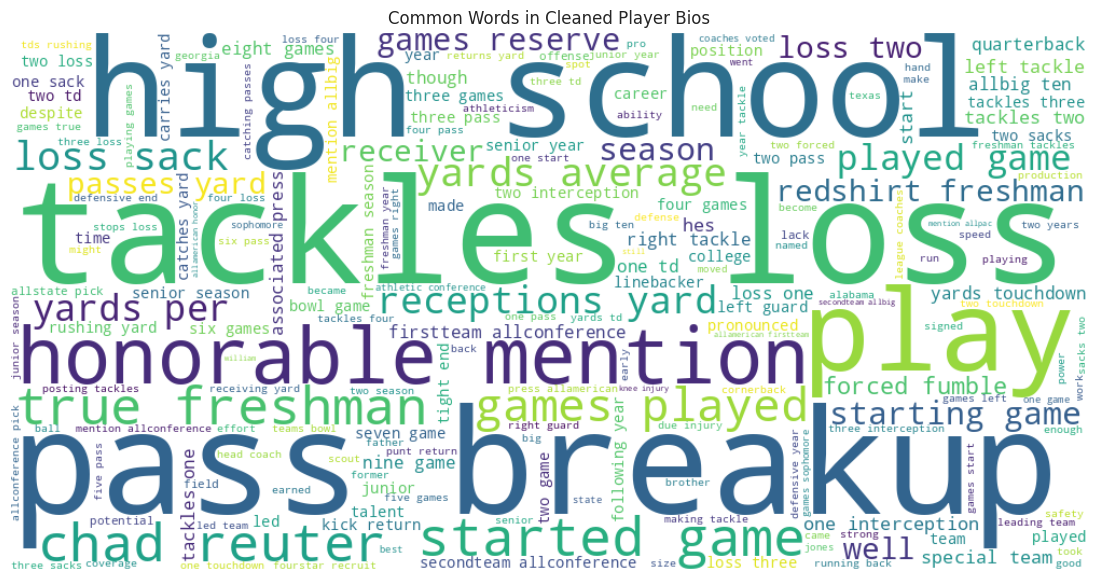

In [9]:
bio_text = " ".join(nfl_prospects_df["Cleaned Bio"].dropna().tolist())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate(bio_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Cleaned Player Bios")
plt.show()

## Data Quality Checks

Rows missing player grades or bios are removed, and player grades are standardized as numeric values.

In [10]:
nfl_prospects_df = nfl_prospects_df.dropna(subset=["Player Grades", "Player Bio"]).copy()
nfl_prospects_df["Player Grades"] = pd.to_numeric(nfl_prospects_df["Player Grades"], errors="coerce")
nfl_prospects_df = nfl_prospects_df.dropna(subset=["Player Grades"]).copy()

nfl_prospects_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         4382 non-null   object 
 1   Player Bio     4382 non-null   object 
 2   Player Grades  4382 non-null   float64
 3   Draft Class    4382 non-null   int64  
 4   Cleaned Bio    4382 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 171.3+ KB


In [11]:
# Feature: Bio length
nfl_prospects_df["Bio Length"] = nfl_prospects_df["Cleaned Bio"].apply(lambda x: len(str(x).split()))
nfl_prospects_df[["Player", "Player Grades", "Bio Length"]].head()

,Player,Player Grades,Bio Length
0,Jadeveon Clowney,7.5,69
1,Sammy Watkins,7.1,38
2,Anthony Barr,7.0,41
3,Khalil Mack,7.0,51
4,Jake Matthews,7.0,31


## Load Draft Results

The second dataset contains actual draft outcomes, including round, pick, and position.

In [12]:
full_draft_df = pd.read_csv("all_decade_draft.csv")
full_draft_df.head()

,Draft Class,Rnd,Pick,Player,Pos
0,2014,1,1,Jadeveon Clowney,DE
1,2014,1,2,Greg Robinson,OT
2,2014,1,3,Blake Bortles,QB
3,2014,1,4,Sammy Watkins,WR
4,2014,1,5,Khalil Mack,LB


## Merge Prospect Bios with Draft Results

The two datasets are merged by player name and draft class to compare pre-draft language with actual draft outcomes.

In [13]:
drafted_players_df = pd.merge(
    full_draft_df,
    nfl_prospects_df,
    on=["Player", "Draft Class"],
    how="left"
)

drafted_players_df.head()

,Draft Class,Rnd,Pick,Player,Pos,Player Bio,Player Grades,Cleaned Bio,Bio Length
0,2014,1,1,Jadeveon Clowney,DE,A physical specimen with a rare size-speed com...,7.5,physical specimen rare sizespeed combination c...,69.0
1,2014,1,2,Greg Robinson,OT,"Big, strong, athletic, overpowering left tackl...",7.0,big strong athletic overpowering left tackle r...,36.0
2,2014,1,3,Blake Bortles,QB,"Big, athletic, ascending quarterback with enou...",6.8,big athletic ascending quarterback enough arm ...,28.0
3,2014,1,4,Sammy Watkins,WR,A legitimate No. 1-caliber receiver who steppe...,7.1,legitimate caliber receiver stepped onto field...,38.0
4,2014,1,5,Khalil Mack,LB,A havoc-wreaking rush linebacker with the burs...,7.0,havocwreaking rush linebacker burst accelerati...,51.0


In [14]:
drafted_players_df.isnull().sum()

,0
Draft Class,0
Rnd,0
Pick,0
Player,0
Pos,0
Player Bio,510
Player Grades,510
Cleaned Bio,510
Bio Length,510


## Impute Missing Player Grades

Missing player grades are imputed using the mean grade for the same draft pick when available, and otherwise the overall mean grade.

In [15]:
mean_grades_by_pick = drafted_players_df.groupby("Pick")["Player Grades"].transform("mean")
overall_mean_grade = drafted_players_df["Player Grades"].mean()

drafted_players_df["Player Grades"] = drafted_players_df["Player Grades"].fillna(mean_grades_by_pick)
drafted_players_df["Player Grades"] = drafted_players_df["Player Grades"].fillna(overall_mean_grade)

drafted_players_df["Player Grades"].isnull().sum()

np.int64(0)

## Sentiment Scoring and Outcome Categories

In [16]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

drafted_players_df["Sentiment Score"] = drafted_players_df["Cleaned Bio"].apply(get_sentiment)

In [17]:
def categorize_success(grade):
    if pd.isna(grade):
        return "No grade"
    elif grade >= 8.0:
        return "The perfect prospect"
    elif 7.3 <= grade <= 7.5:
        return "Perennial All-Pro"
    elif 7.0 <= grade < 7.3:
        return "Pro Bowl talent"
    elif 6.7 <= grade < 7.0:
        return "Year 1 starter"
    elif 6.5 <= grade < 6.7:
        return "Boom-or-bust prospect"
    elif 6.3 <= grade < 6.5:
        return "Will become a good starter"
    elif 6.1 <= grade < 6.3:
        return "Good backup with potential to develop into starter"
    elif 5.8 <= grade < 6.1:
        return "Average backup / special-teamer"
    elif 5.6 <= grade < 5.8:
        return "Candidate for bottom of roster or practice squad"
    else:
        return "Poor prospect"

drafted_players_df["Expected Success"] = drafted_players_df["Player Grades"].apply(categorize_success)

In [18]:
drafted_players_df = drafted_players_df[
    ["Player", "Draft Class", "Rnd", "Pick", "Pos", "Player Grades",
     "Expected Success", "Sentiment Score", "Bio Length"]
].copy()

drafted_players_df.head()

,Player,Draft Class,Rnd,Pick,Pos,Player Grades,Expected Success,Sentiment Score,Bio Length
0,Jadeveon Clowney,2014,1,1,DE,7.5,Perennial All-Pro,0.179861,69.0
1,Greg Robinson,2014,1,2,OT,7.0,Pro Bowl talent,0.055840,36.0
2,Blake Bortles,2014,1,3,QB,6.8,Year 1 starter,0.320000,28.0
3,Sammy Watkins,2014,1,4,WR,7.1,Pro Bowl talent,0.336667,38.0
4,Khalil Mack,2014,1,5,LB,7.0,Pro Bowl talent,0.024150,51.0


## Sentiment, Player Grades, and Bio Length

This visualization compares sentiment score and player grade, with bubble size representing bio length.

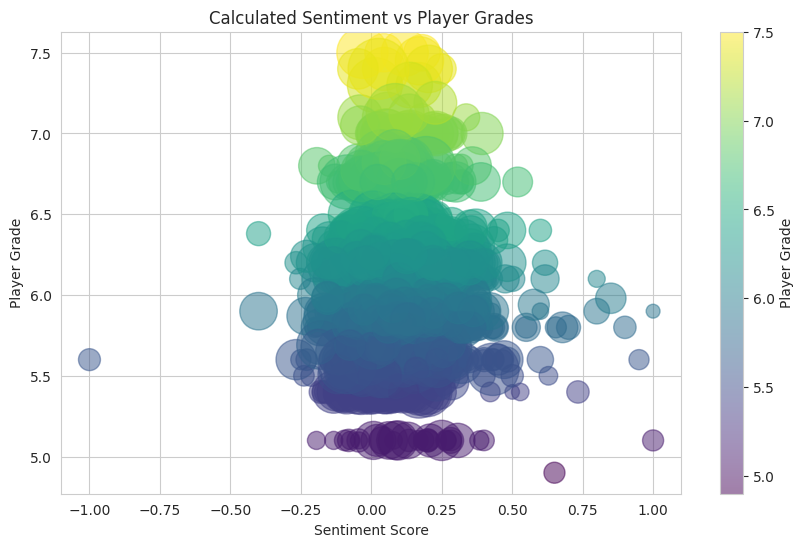

In [19]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    drafted_players_df["Sentiment Score"],
    drafted_players_df["Player Grades"],
    s=drafted_players_df["Bio Length"] * 10,
    alpha=0.5,
    c=drafted_players_df["Player Grades"],
    cmap="viridis"
)

plt.xlabel("Sentiment Score")
plt.ylabel("Player Grade")
plt.title("Calculated Sentiment vs Player Grades")
plt.colorbar(scatter, label="Player Grade")
plt.show()

## Distribution of Player Grades by Expected Success

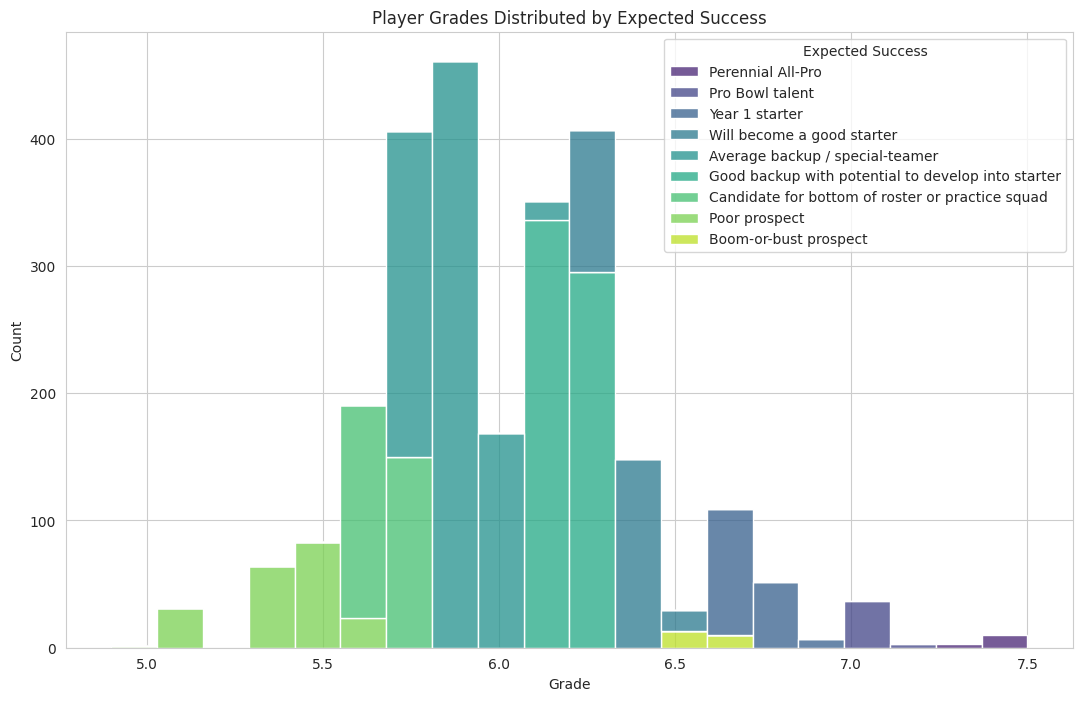

In [20]:
plt.figure(figsize=(13, 8))
sns.histplot(
    data=drafted_players_df,
    x="Player Grades",
    hue="Expected Success",
    multiple="stack",
    bins=20,
    palette="viridis"
)

plt.title("Player Grades Distributed by Expected Success")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

## Average Prospect Grades by Draft Class

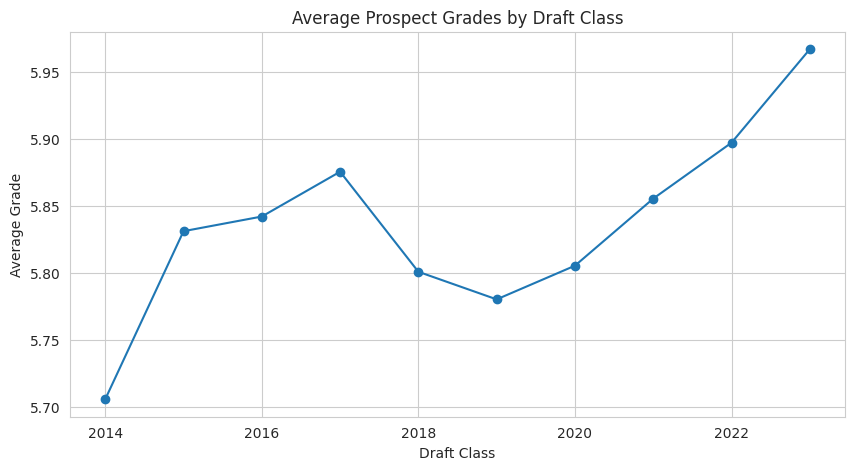

In [21]:
avg_grades = nfl_prospects_df.groupby("Draft Class")["Player Grades"].mean().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(avg_grades.index, avg_grades.values, marker="o")
plt.title("Average Prospect Grades by Draft Class")
plt.xlabel("Draft Class")
plt.ylabel("Average Grade")
plt.show()

## Number of Prospects by Draft Class

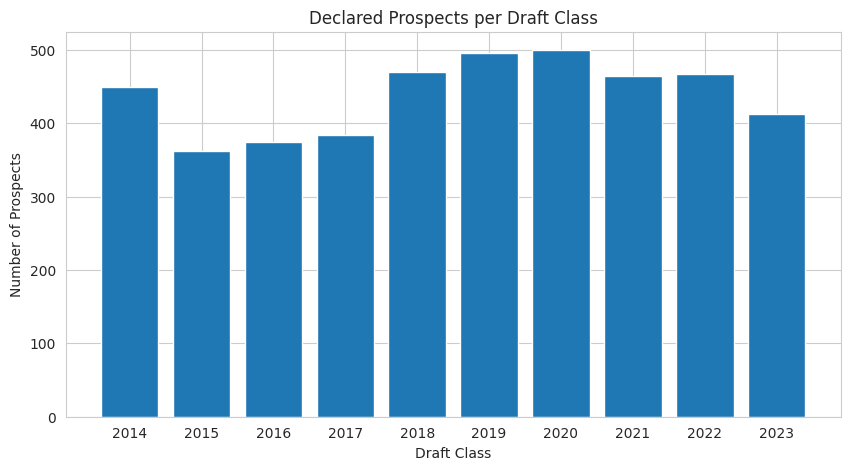

In [22]:
counts = nfl_prospects_df["Draft Class"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Declared Prospects per Draft Class")
plt.xlabel("Draft Class")
plt.ylabel("Number of Prospects")
plt.show()

## Sentiment of 2023 Draft Selections

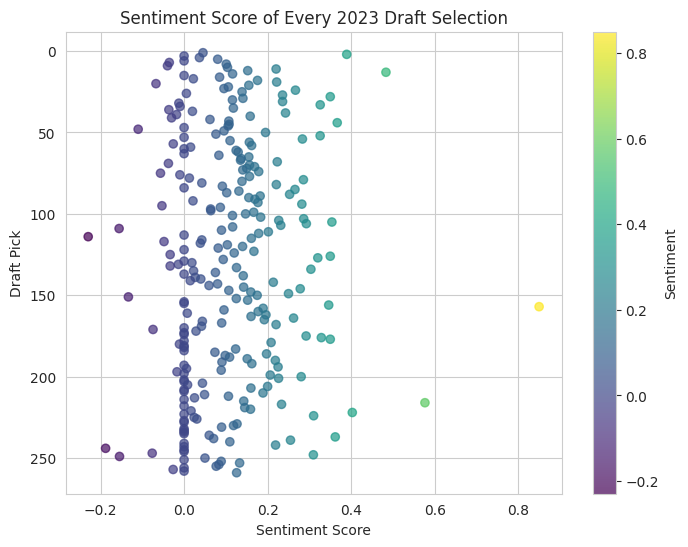

In [23]:
df_2023 = drafted_players_df[drafted_players_df["Draft Class"] == 2023].copy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_2023["Sentiment Score"],
    df_2023["Pick"],
    c=df_2023["Sentiment Score"],
    cmap="viridis",
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.xlabel("Sentiment Score")
plt.ylabel("Draft Pick")
plt.title("Sentiment Score of Every 2023 Draft Selection")
plt.colorbar(scatter, label="Sentiment")
plt.show()

## Sentiment by Draft Round in 2023

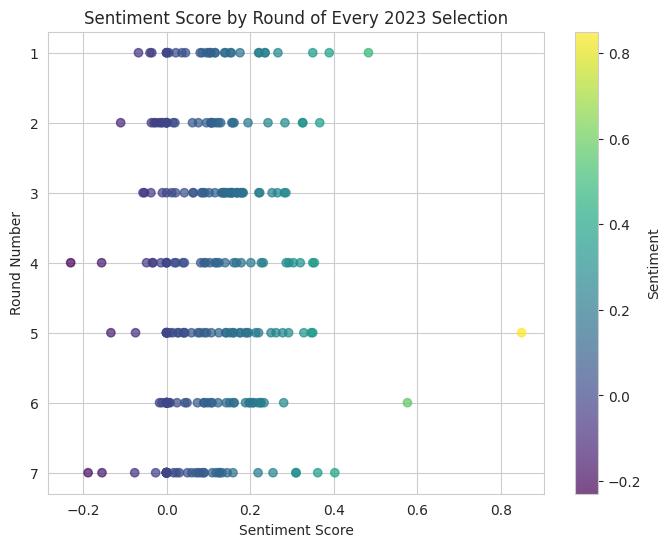

In [24]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_2023["Sentiment Score"],
    df_2023["Rnd"],
    c=df_2023["Sentiment Score"],
    cmap="viridis",
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.xlabel("Sentiment Score")
plt.ylabel("Round Number")
plt.title("Sentiment Score by Round of Every 2023 Selection")
plt.colorbar(scatter, label="Sentiment")
plt.show()

## Sentiment Distribution by Draft Class and Position Group

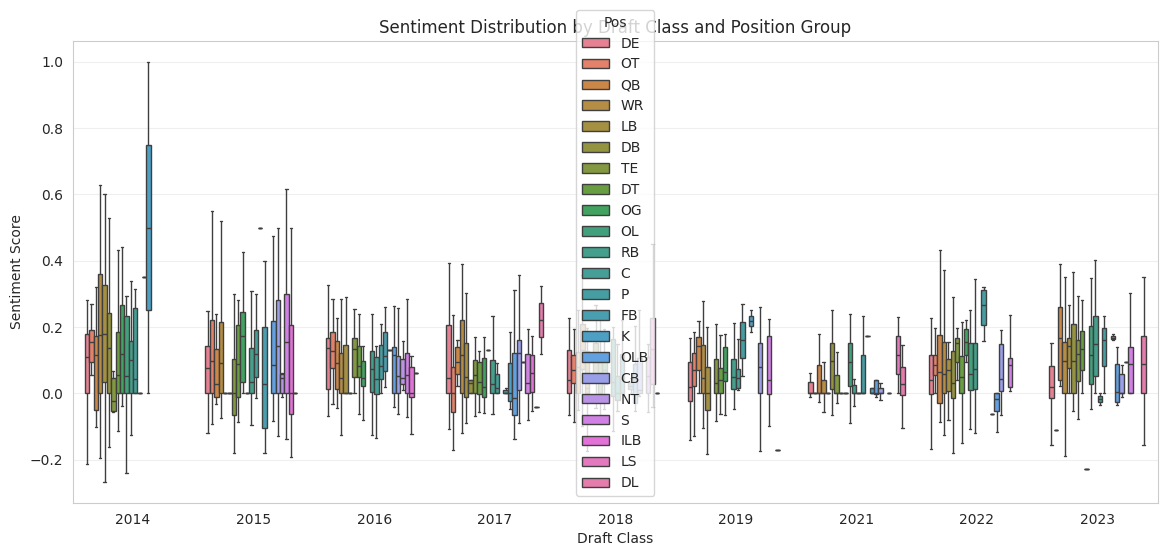

In [25]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=drafted_players_df,
    x="Draft Class",
    y="Sentiment Score",
    hue="Pos",
    showfliers=False
)

plt.title("Sentiment Distribution by Draft Class and Position Group")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Average Sentiment by Position and Draft Class

In [26]:
avg_sentiment = (
    drafted_players_df.groupby(["Draft Class", "Pos"])["Sentiment Score"]
    .mean()
    .reset_index()
    .rename(columns={"Sentiment Score": "Avg Sentiment Score"})
)

pivot_table = avg_sentiment.pivot(
    index="Draft Class",
    columns="Pos",
    values="Avg Sentiment Score"
)

pivot_table.head()

Pos,C,CB,DB,DE,DL,DT,FB,ILB,K,LB,...,OG,OL,OLB,OT,P,QB,RB,S,TE,WR
Draft Class,,,,,,,,,,,,,,,,,,,,,
2014,0.200351,NaN,0.146016,0.062773,NaN,0.103546,0.350000,NaN,0.500000,0.208391,...,0.160977,0.129889,NaN,0.153556,0.000000,0.016171,0.084446,NaN,-0.042005,0.196621
2015,0.126142,0.148799,0.000000,0.078680,NaN,0.122059,0.068333,0.090268,NaN,0.000000,...,0.177251,0.000000,0.124208,0.157036,0.500000,0.068485,0.069762,0.164774,0.022939,0.120356
2016,0.035466,0.065846,0.000000,0.124041,NaN,0.092254,0.130897,0.013394,0.131964,0.097222,...,0.084619,NaN,0.112256,0.125839,0.097222,0.084771,0.081434,0.064332,0.117666,0.063704
2017,0.032235,0.099860,0.092951,0.093353,0.221301,0.040432,0.005774,0.060069,0.045515,0.079571,...,0.045311,0.129556,0.031014,0.011921,NaN,0.111013,0.051276,0.054005,0.038043,0.136820
2018,0.028115,0.069951,NaN,0.067877,NaN,0.060125,NaN,0.155453,0.023214,0.050290,...,0.072447,NaN,0.046314,0.078336,0.076269,0.073899,0.063356,0.049000,0.100877,0.133122


In [27]:
positions_remove = ["K", "P", "LS"]
filtered_positions = pivot_table.columns.difference(positions_remove)

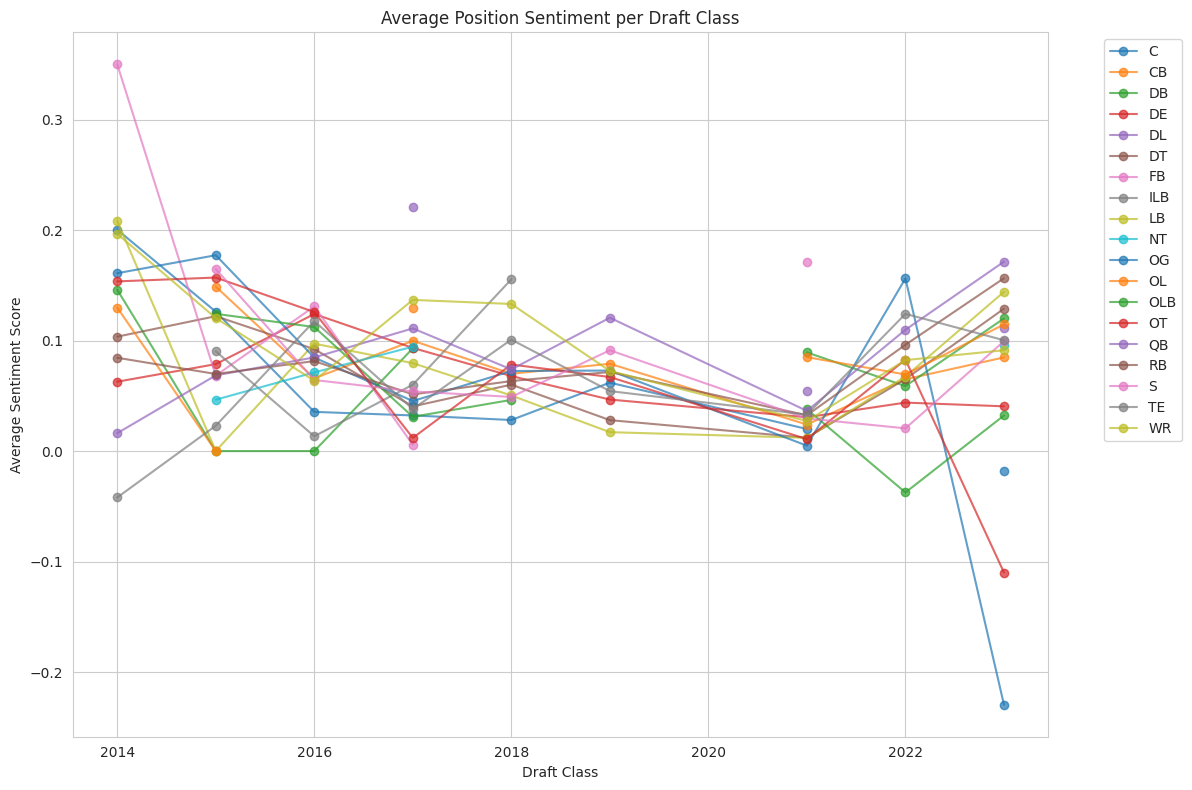

In [28]:
plt.figure(figsize=(12, 8))

for pos in filtered_positions:
    plt.plot(
        pivot_table.index,
        pivot_table[pos],
        marker="o",
        label=pos,
        alpha=0.7
    )

plt.title("Average Position Sentiment per Draft Class")
plt.xlabel("Draft Class")
plt.ylabel("Average Sentiment Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Heatmap of Average Positional Sentiment

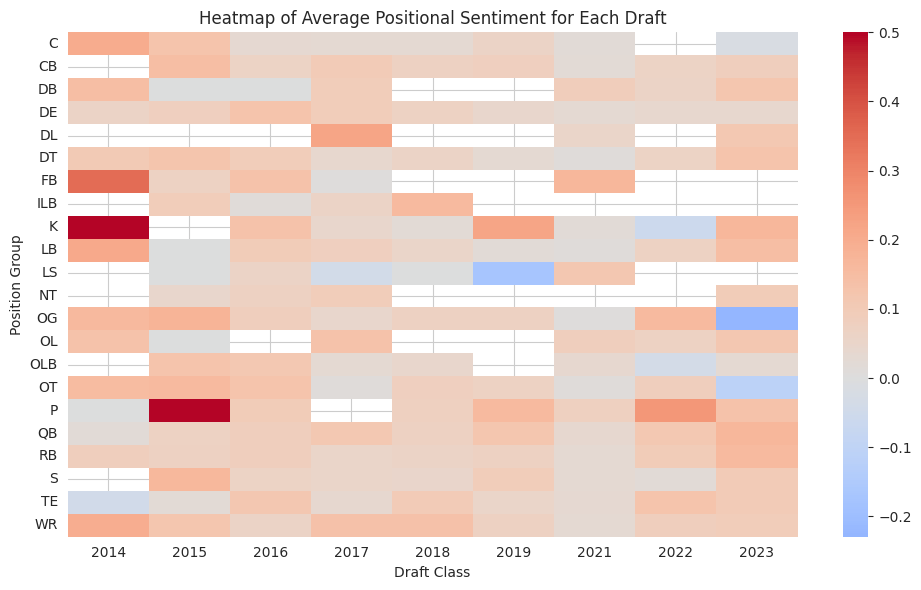

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table.T, annot=False, cmap="coolwarm", center=0)
plt.title("Heatmap of Average Positional Sentiment for Each Draft")
plt.xlabel("Draft Class")
plt.ylabel("Position Group")
plt.tight_layout()
plt.show()

## Relationship between Sentiment Score and Draft Position

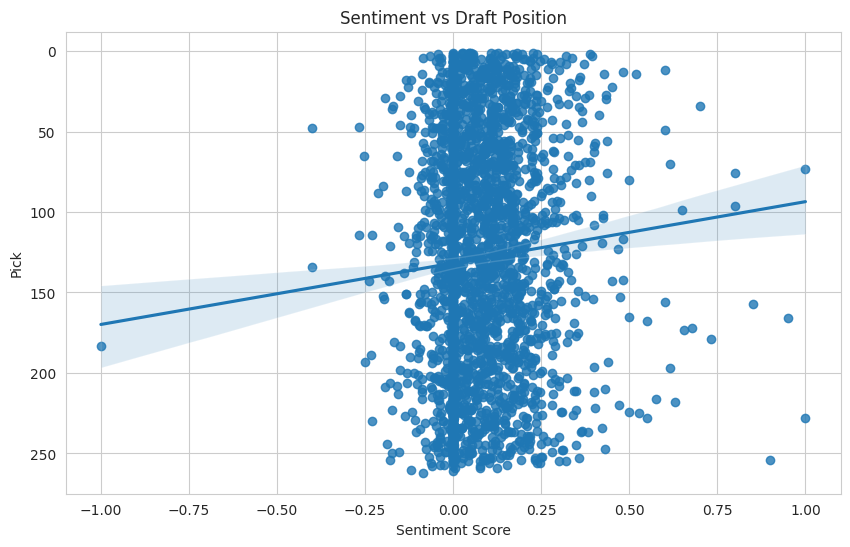

In [31]:
sns.regplot(
    data=drafted_players_df,
    x="Sentiment Score",
    y="Pick"
)
plt.gca().invert_yaxis()
plt.title("Sentiment vs Draft Position")
plt.show()

## Conclusion

Sentiment analysis provides a useful quantitative lens for studying how NFL prospects are described before the draft. This project highlights patterns in perceived player value across years, rounds, and position groups by combining scouting language with draft outcomes.